In [1]:
# ═══════════════════════════════════════════════════════════
# Cell 1 — 风险分级实验：基于图像+KG 的多分类
# 任务：high risk / moderate risk / healthy / very healthy
# ═══════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network  import MLPClassifier
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.metrics         import (accuracy_score, f1_score,
                                     classification_report, confusion_matrix,
                                     roc_auc_score)
from sklearn.model_selection  import StratifiedKFold, train_test_split
from sklearn.multiclass       import OneVsRestClassifier



In [2]:


sns.set_theme(style="whitegrid", palette="muted")
OUT_DIR = Path("kg_output")
SEED    = 42

nodes_df = pd.read_csv(OUT_DIR / "kg_nodes.csv")
edges_df = pd.read_csv(OUT_DIR / "kg_edges.csv")

# 加载已提取的图像 embedding
X_img    = np.load(OUT_DIR / "img_embeddings.npy")
y_bin    = np.load(OUT_DIR / "img_labels.npy")
splits   = np.load(OUT_DIR / "img_splits.npy")

print(f"Image embeddings: {X_img.shape}")
print(f"Binary labels   : glaucoma={y_bin.sum()}, normal={(1-y_bin).sum()}")



Image embeddings: (689, 2048)
Binary labels   : glaucoma=427, normal=262


In [3]:



# ═══════════════════════════════════════════════════════════
# Cell 2 — 构建风险分级标签
# ═══════════════════════════════════════════════════════════

# FundusImage -> filename
img_nodes = nodes_df[nodes_df.label == "FundusImage"][["id","filename"]].rename(columns={"id":"img_id"})

# img_id -> diag_id -> risk_assessment
has_diag  = edges_df[edges_df.rel == "HAS_DIAGNOSIS"][["src","dst"]].rename(
            columns={"src":"img_id","dst":"diag_id"})
diag_nodes= nodes_df[nodes_df.label == "Diagnosis"][["id","risk_assessment"]].rename(
            columns={"id":"diag_id"})

img_risk = (img_nodes
            .merge(has_diag,   on="img_id")
            .merge(diag_nodes, on="diag_id"))

fn_to_risk = dict(zip(img_risk["filename"], img_risk["risk_assessment"]))

# 加载 all_records 的 filename 顺序（与 X_img 对齐）
import pyarrow.parquet as pq
DATA_DIR = Path("Dataset/Data")

def load_filenames(parquet_path):
    table = pq.read_table(parquet_path, columns=["filename","annotation"])
    df    = table.to_pandas()
    return df["filename"].tolist(), df["annotation"].tolist()

train_fns, train_anns = load_filenames(DATA_DIR / "train-00000-of-00001.parquet")
test_fns,  test_anns  = load_filenames(DATA_DIR / "test-00000-of-00001.parquet")
all_fns  = train_fns + test_fns
all_anns = train_anns + test_anns

# 构建风险标签
risk_labels = [fn_to_risk.get(fn, "unknown") for fn in all_fns]
risk_series = pd.Series(risk_labels)

print("\nRisk label distribution:")
print(risk_series.value_counts())

# 过滤掉 unknown
valid_mask = risk_series != "unknown"
X_valid    = X_img[valid_mask]
risk_valid = risk_series[valid_mask].values
ann_valid  = np.array(all_anns)[valid_mask]

# 编码标签
le = LabelEncoder()
y_risk = le.fit_transform(risk_valid)
print(f"\nEncoded classes: {list(le.classes_)}")
print(f"Valid samples  : {len(y_risk)}")




Risk label distribution:
high risk        381
very healthy     255
moderate risk     46
healthy            7
Name: count, dtype: int64

Encoded classes: ['healthy', 'high risk', 'moderate risk', 'very healthy']
Valid samples  : 689


In [4]:


# ═══════════════════════════════════════════════════════════
# Cell 3 — KG chain features 对齐
# ═══════════════════════════════════════════════════════════

sup_edges    = edges_df[edges_df.rel == "SUPPORTS_RULE"].copy()
rules_df_kg  = nodes_df[nodes_df.label == "ClinicalRule"].copy()
strength_map = {}
for _, row in rules_df_kg.iterrows():
    strength_map[str(row["id"])] = str(row["strength"]).strip().lower()

diag_counts = defaultdict(lambda: {"strong":0,"moderate":0,"weak":0})
for _, row in sup_edges.iterrows():
    d = str(row["src"]); r = str(row["dst"])
    s = strength_map.get(r, "weak")
    diag_counts[d][s] += 1

chain_records = []
for diag_id, c in diag_counts.items():
    chain_records.append({
        "diag_id":     diag_id,
        "chain_score": c["strong"]*3 + c["moderate"]*2 + c["weak"]*1,
        "n_strong":    c["strong"],
        "n_moderate":  c["moderate"],
        "n_weak":      c["weak"],
        "n_rules":     sum(c.values()),
    })
chain_df = pd.DataFrame(chain_records)

img_chain = img_nodes.merge(has_diag, on="img_id").merge(chain_df, on="diag_id")
fn_to_chain = img_chain.set_index("filename")[
    ["chain_score","n_strong","n_moderate","n_weak","n_rules"]
].to_dict("index")

KG_COLS = ["chain_score","n_strong","n_moderate","n_weak","n_rules"]
X_kg_all = []
all_fns_arr = np.array(all_fns)
for fn in all_fns_arr[valid_mask]:
    row = fn_to_chain.get(fn, {c:0 for c in KG_COLS})
    X_kg_all.append([row.get(c,0) for c in KG_COLS])
X_kg_valid = np.array(X_kg_all, dtype=float)

scaler_img = StandardScaler()
scaler_kg  = StandardScaler()
X_img_s    = scaler_img.fit_transform(X_valid)
X_img_kg_s = scaler_kg.fit_transform(np.hstack([X_valid, X_kg_valid]))

print(f"X_img_s shape   : {X_img_s.shape}")
print(f"X_img_kg_s shape: {X_img_kg_s.shape}")



X_img_s shape   : (689, 2048)
X_img_kg_s shape: (689, 2053)


In [5]:


# ═══════════════════════════════════════════════════════════
# Cell 4 — 多分类评估函数
# ═══════════════════════════════════════════════════════════

def evaluate_multi(y_true, y_pred, y_prob, classes):
    acc    = accuracy_score(y_true, y_pred)
    f1_mac = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    f1_wt  = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    except Exception:
        auc = float("nan")
    return {
        "Accuracy":    round(acc,    4),
        "F1 (macro)":  round(f1_mac, 4),
        "F1 (weighted)": round(f1_wt, 4),
        "AUC (macro)": round(auc,    4),
    }

def run_cv_multi(model, X, y, n_splits=5):
    skf    = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    scores = []
    for tr, val in skf.split(X, y):
        model.fit(X[tr], y[tr])
        yp    = model.predict(X[val])
        yprob = model.predict_proba(X[val])
        scores.append(evaluate_multi(y[val], yp, yprob, le.classes_))
    return pd.DataFrame(scores).mean().round(4)

print("Evaluation functions ready.")



Evaluation functions ready.


In [7]:


# ═══════════════════════════════════════════════════════════
# Cell 5 — 对比实验（风险分级）
# ═══════════════════════════════════════════════════════════

experiments = [
    ("B1 LR  (img)",  LogisticRegression(max_iter=1000, random_state=SEED), X_img_s),
    ("B2 RF  (img)",  RandomForestClassifier(n_estimators=200, random_state=SEED), X_img_s),
    ("B3 GB  (img)",  GradientBoostingClassifier(n_estimators=100, random_state=SEED), X_img_s),
    ("B4 MLP (img)",  MLPClassifier(hidden_layer_sizes=(256,64), max_iter=500,
                                     random_state=SEED), X_img_s),
    ("Ours (img+KG)", GradientBoostingClassifier(n_estimators=100, random_state=SEED), X_img_kg_s),
]

results = {}
for name, clf, X in experiments:
    print(f"Running {name}...")
    scores = run_cv_multi(clf, X, y_risk)
    results[name] = scores.to_dict()
    print(f"  F1(mac)={scores['F1 (macro)']:.4f}  AUC={scores['AUC (macro)']:.4f}")

results_df = pd.DataFrame(results).T
results_df.index.name = "Method"
print("\n=== Risk Stratification Results ===")
print(results_df.to_string())




Running B1 LR  (img)...
  F1(mac)=0.5343  AUC=0.7752
Running B2 RF  (img)...
  F1(mac)=0.4746  AUC=0.8382
Running B3 GB  (img)...
  F1(mac)=0.5343  AUC=0.7774
Running B4 MLP (img)...
  F1(mac)=0.5370  AUC=0.8286
Running Ours (img+KG)...
  F1(mac)=0.6127  AUC=0.8010

=== Risk Stratification Results ===
               Accuracy  F1 (macro)  F1 (weighted)  AUC (macro)
Method                                                         
B1 LR  (img)     0.8316      0.5343         0.8230       0.7752
B2 RF  (img)     0.8012      0.4746         0.7802       0.8382
B3 GB  (img)     0.8273      0.5343         0.8205       0.7774
B4 MLP (img)     0.8186      0.5370         0.8110       0.8286
Ours (img+KG)    0.9303      0.6127         0.9222       0.8010


In [8]:

# ═══════════════════════════════════════════════════════════
# Cell 6 — KG 融合权重消融（风险分级）
# ═══════════════════════════════════════════════════════════

# 先得到图像模型的类别概率
base_clf = GradientBoostingClassifier(n_estimators=100, random_state=SEED)
skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

img_probs = np.zeros((len(y_risk), len(le.classes_)))
for tr, val in skf.split(X_img_s, y_risk):
    base_clf.fit(X_img_s[tr], y_risk[tr])
    img_probs[val] = base_clf.predict_proba(X_img_s[val])

# KG chain_score → 转为风险等级概率分布
# high risk=3, moderate risk=2, healthy=1, very healthy=0
# chain_score 越高 → high risk 概率越大
chain_scores = X_kg_valid[:, 0]
cs_norm      = (chain_scores - chain_scores.min()) / (chain_scores.max() - chain_scores.min() + 1e-8)

# 构建 KG 伪概率：[very healthy, healthy, moderate, high] 按 chain_score 分布
classes_sorted = list(le.classes_)
print(f"Classes: {classes_sorted}")

def chain_to_prob(cs_norm_val, n_classes):
    # cs_norm=0 → very healthy; cs_norm=1 → high risk
    probs = np.zeros(n_classes)
    for i, cls in enumerate(classes_sorted):
        if cls == "high risk":
            probs[i] = cs_norm_val
        elif cls == "moderate risk":
            probs[i] = cs_norm_val * 0.5
        elif cls == "healthy":
            probs[i] = (1 - cs_norm_val) * 0.3
        elif cls == "very healthy":
            probs[i] = (1 - cs_norm_val)
    # normalize
    s = probs.sum()
    return probs / s if s > 0 else probs

kg_probs = np.array([chain_to_prob(v, len(le.classes_)) for v in cs_norm])

ablation_results = {}
for alpha in [0.0, 0.3, 0.5, 0.7, 1.0]:
    fused = (1 - alpha) * img_probs + alpha * kg_probs
    pred  = np.argmax(fused, axis=1)
    name  = f"α={alpha}"
    sc    = evaluate_multi(y_risk, pred, fused, le.classes_)
    ablation_results[name] = sc
    print(f"{name}: F1(mac)={sc['F1 (macro)']:.4f}  AUC={sc['AUC (macro)']:.4f}")

ablation_df = pd.DataFrame(ablation_results).T
print("\n=== Ablation: KG fusion weight (risk stratification) ===")
print(ablation_df.to_string())



Classes: ['healthy', 'high risk', 'moderate risk', 'very healthy']
α=0.0: F1(mac)=0.5360  AUC=0.7793
α=0.3: F1(mac)=0.5487  AUC=0.8679
α=0.5: F1(mac)=0.5706  AUC=0.8525
α=0.7: F1(mac)=0.5435  AUC=0.8429
α=1.0: F1(mac)=0.4254  AUC=0.8085

=== Ablation: KG fusion weight (risk stratification) ===
       Accuracy  F1 (macro)  F1 (weighted)  AUC (macro)
α=0.0    0.8273      0.5360         0.8213       0.7793
α=0.3    0.8476      0.5487         0.8409       0.8679
α=0.5    0.8897      0.5706         0.8799       0.8525
α=0.7    0.9173      0.5435         0.8960       0.8429
α=1.0    0.8200      0.4254         0.7939       0.8085


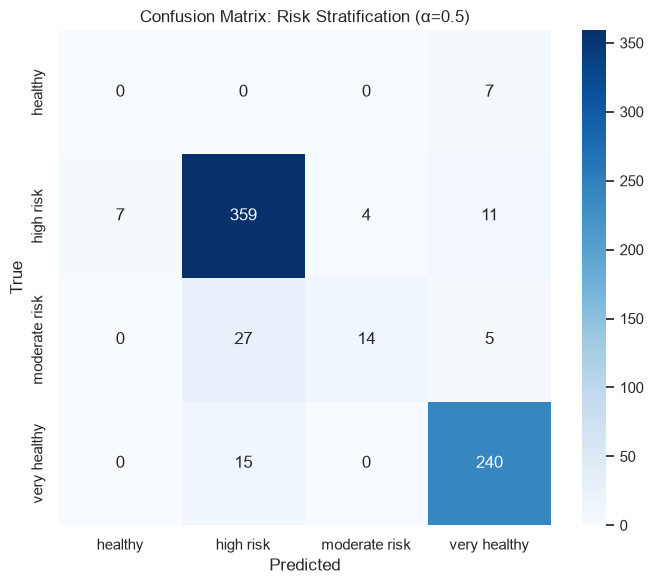

In [9]:


# ═══════════════════════════════════════════════════════════
# Cell 7 — 混淆矩阵（最优模型）
# ═══════════════════════════════════════════════════════════

# 用 α=0.5 的融合结果
fused_best = 0.5 * img_probs + 0.5 * kg_probs
pred_best  = np.argmax(fused_best, axis=1)

cm = confusion_matrix(y_risk, pred_best)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix: Risk Stratification (α=0.5)")
plt.tight_layout()
plt.savefig(OUT_DIR / "exp_risk_confusion.png", dpi=150)
plt.show()



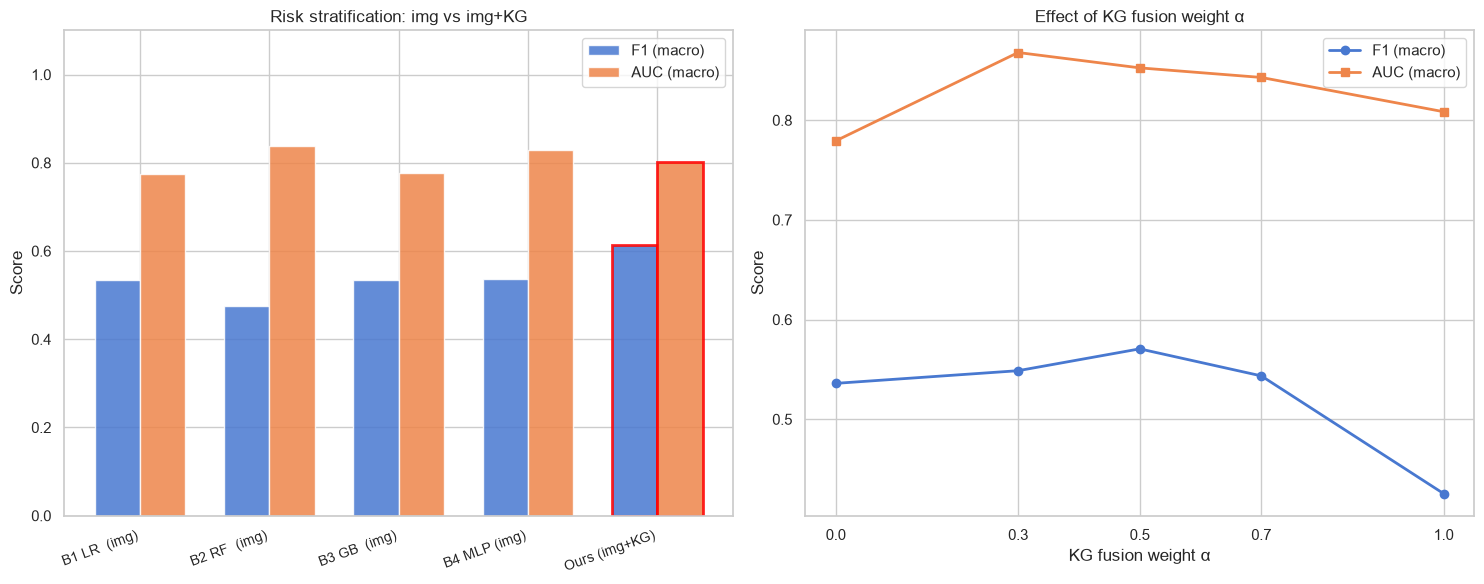

TABLE: Risk Stratification Comparison
Method                        Acc   F1(mac)   F1(wt)     AUC
------------------------------------------------------------------------
B1 LR  (img)               0.8316    0.5343   0.8230  0.7752
B2 RF  (img)               0.8012    0.4746   0.7802  0.8382
B3 GB  (img)               0.8273    0.5343   0.8205  0.7774
B4 MLP (img)               0.8186    0.5370   0.8110  0.8286
Ours (img+KG)              0.9303    0.6127   0.9222  0.8010 ◀

TABLE: KG Fusion Weight Ablation (Risk Stratification)
Method                        Acc   F1(mac)   F1(wt)     AUC
------------------------------------------------------------------------
α=0.0                      0.8273    0.5360   0.8213  0.7793
α=0.3                      0.8476    0.5487   0.8409  0.8679
α=0.5                      0.8897    0.5706   0.8799  0.8525 ◀
α=0.7                      0.9173    0.5435   0.8960  0.8429
α=1.0                      0.8200    0.4254   0.7939  0.8085

Figures saved:
  kg_out

In [10]:


# ═══════════════════════════════════════════════════════════
# Cell 8 — 可视化对比 + 消融
# ═══════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 对比图
methods = list(results_df.index)
x = np.arange(len(methods))
w = 0.35
bars1 = axes[0].bar(x - w/2, results_df["F1 (macro)"],  w, label="F1 (macro)",  alpha=0.85)
bars2 = axes[0].bar(x + w/2, results_df["AUC (macro)"], w, label="AUC (macro)", alpha=0.85)
for i, m in enumerate(methods):
    if "Ours" in m:
        bars1[i].set_edgecolor("red"); bars1[i].set_linewidth(2)
        bars2[i].set_edgecolor("red"); bars2[i].set_linewidth(2)
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, rotation=20, ha="right", fontsize=10)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel("Score")
axes[0].set_title("Risk stratification: img vs img+KG")
axes[0].legend()

# 消融图（α sweep）
alphas = [float(k.split("=")[1]) for k in ablation_df.index]
axes[1].plot(alphas, ablation_df["F1 (macro)"],  "o-", label="F1 (macro)",  lw=2)
axes[1].plot(alphas, ablation_df["AUC (macro)"], "s-", label="AUC (macro)", lw=2)
axes[1].set_xlabel("KG fusion weight α")
axes[1].set_ylabel("Score")
axes[1].set_title("Effect of KG fusion weight α")
axes[1].legend()
axes[1].set_xticks(alphas)

plt.tight_layout()
plt.savefig(OUT_DIR / "exp_risk_comparison.png", dpi=150)
plt.show()


# ═══════════════════════════════════════════════════════════
# Cell 9 — 论文 Table
# ═══════════════════════════════════════════════════════════
print("=" * 72)
print("TABLE: Risk Stratification Comparison")
print("=" * 72)
header = f"{'Method':<25} {'Acc':>7} {'F1(mac)':>9} {'F1(wt)':>8} {'AUC':>7}"
print(header)
print("-" * 72)
for method, row in results_df.iterrows():
    marker = " ◀" if "Ours" in method else ""
    print(f"{method:<25} {row['Accuracy']:>7.4f} {row['F1 (macro)']:>9.4f} "
          f"{row['F1 (weighted)']:>8.4f} {row['AUC (macro)']:>7.4f}{marker}")

print("\n" + "=" * 72)
print("TABLE: KG Fusion Weight Ablation (Risk Stratification)")
print("=" * 72)
print(header)
print("-" * 72)
for method, row in ablation_df.iterrows():
    marker = " ◀" if method == "α=0.5" else ""
    print(f"{method:<25} {row['Accuracy']:>7.4f} {row['F1 (macro)']:>9.4f} "
          f"{row['F1 (weighted)']:>8.4f} {row['AUC (macro)']:>7.4f}{marker}")

print(f"\nFigures saved:")
print(f"  kg_output/exp_risk_confusion.png")
print(f"  kg_output/exp_risk_comparison.png")